1. Let User extract 24-hour RRFS Model data for a given date and hour when prompted.

   This will be for PWAT, PWAT (Precipitable Water):
    The depth of liquid water if all the vertical column water vapor were condensed.
        High PWAT = High Moisture Content in clouds.

   Pull hourly water vapor data for given date and forecast hour.
   
3. Map that selected data with cartopy, as done before with surface temperature data, after finding max/min for legend intervals.

4. Load Midwest Map data to csv.

5. Geocode (reverse geocode) midwest map data to State names.
    By spatially joining or using hourly PWAT point data in pandas dataframe within state borders.

6. Calculate average water vapor or precipitation depth that would fall if fully condensed at a provided date, hour for the prompted state.

In [1]:
from herbie import Herbie
from herbie import HerbieLatest

import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import geopandas as gpd
from shapely.geometry import Point

In [3]:
# Prompt for model initialization date
date_input = input("Enter model initialization date (Format: YYYY-MM-DD): ").strip()

# 08:00 ET aligns with the 12:00 UTC model run, to allow for up to 60/84 hours ahead
user_input_et = f"{date_input} 08:00"

# Convert ET to UTC\
dt_et = pd.to_datetime(user_input_et)
dt_utc = (
    dt_et.tz_localize("America/New_York", ambiguous="NaT", nonexistent="shift_forward")
    .tz_convert("UTC")
)

init_time_utc = dt_utc.strftime("%Y-%m-%d %H:%M")

print(f"\n--- Processing Model Run ---")
print(f"User Input (ET):  {user_input_et}")
print(f"Converted (UTC):  {init_time_utc}\n")

# Loop through forecast hours 1 to 24, stop if data missing
ds_list = []

for fxx_hour in range(1, 25):
    print(f"Checking RRFS forecast hour: fxx={fxx_hour}")

    try:
        # Initialize Herbie with product="prslev"
        H = Herbie(
            init_time_utc, 
            model="rrfs", 
            product="prslev",
            fxx=fxx_hour, 
            member="control", 
            domain="conus"
        )

        # Hourly water vapor
        ds = H.xarray(":PWAT:")
        ds_list.append(ds)
        
    except (TimeoutError, FileNotFoundError) as e:
        print(f"⚠️ Model data not available past forecast hour {fxx_hour - 1}. STOP.")
        break

print(f"\nSuccess! Loaded {len(ds_list)} available hours into xarray.")

Enter model initialization date (Format: YYYY-MM-DD):  2026-08-06



--- Processing Model Run ---
User Input (ET):  2026-08-06 08:00
Converted (UTC):  2026-08-06 12:00

Checking RRFS forecast hour: fxx=1
✅ Found ┊ model=rrfs ┊ product=prslev ┊ 2026-Aug-06 12:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local
Checking RRFS forecast hour: fxx=2
✅ Found ┊ model=rrfs ┊ product=prslev ┊ 2026-Aug-06 12:00 UTC F02 ┊ GRIB2 @ aws ┊ IDX @ local
Checking RRFS forecast hour: fxx=3
✅ Found ┊ model=rrfs ┊ product=prslev ┊ 2026-Aug-06 12:00 UTC F03 ┊ GRIB2 @ aws ┊ IDX @ local
Checking RRFS forecast hour: fxx=4
✅ Found ┊ model=rrfs ┊ product=prslev ┊ 2026-Aug-06 12:00 UTC F04 ┊ GRIB2 @ aws ┊ IDX @ local
Checking RRFS forecast hour: fxx=5
✅ Found ┊ model=rrfs ┊ product=prslev ┊ 2026-Aug-06 12:00 UTC F05 ┊ GRIB2 @ aws ┊ IDX @ local
Checking RRFS forecast hour: fxx=6
✅ Found ┊ model=rrfs ┊ product=prslev ┊ 2026-Aug-06 12:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ local
Checking RRFS forecast hour: fxx=7
✅ Found ┊ model=rrfs ┊ product=prslev ┊ 2026-Aug-06 12:00 UTC F07 ┊ GRIB2 @ aws ┊ IDX @ lo

In [10]:
# User initiates which forecast hour to map
max_available = len(ds_list)
plot_fxx = int(input(f"Enter the forecast hour you want to plot (1 to {max_available}): "))

if plot_fxx < 1 or plot_fxx > max_available:
    raise ValueError(f"Invalid selection. Please choose between 1 and {max_available}.")

# Select forecast hour with user input plot_fxx
ds = ds_list[plot_fxx - 1]

Enter the forecast hour you want to plot (1 to 24):  3


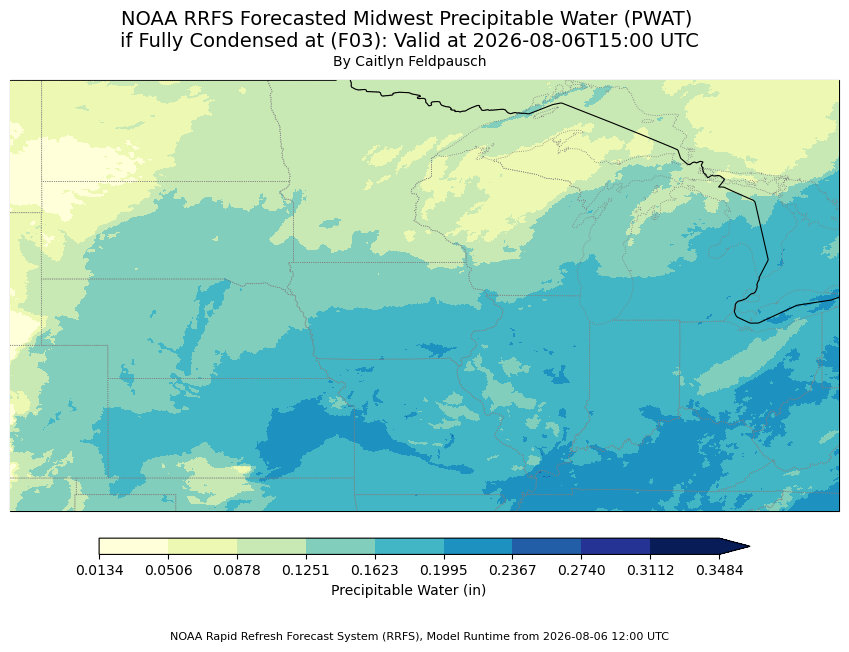

In [55]:
# Extract vars for hourly cumulative water vapor
pwat_mm = ds['pwat'].values
lons = ds.longitude
lats = ds.latitude

# Convert from mm to inches
pwat_in = pwat_mm / 25.4

# Midwest Extent Box [W, E, S, N]
midwest_extent = [-105, -80, 36, 49]  # Precip map for july 31st at 6pm EDT






# Create Figure
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(midwest_extent, crs=ccrs.PlateCarree())

# Add Geographic Features
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue', zorder=1)
ax.add_feature(cfeature.LAND, facecolor='whitesmoke', zorder=1)
ax.add_feature(cfeature.LAKES, facecolor='aliceblue', edgecolor='gray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(
    cfeature.STATES, edgecolor='gray', linestyle=':', linewidth=0.6, zorder=5
)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, zorder=6)

# Define colorbar intervals with min/max of data
data_min = float(np.ma.min(pwat_in))
data_max = float(np.ma.max(pwat_in))
levels = np.linspace(data_min, data_max, num=10)

# Colors
cmap = plt.get_cmap('YlGnBu')
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

# Plot cumulative hourly water vapor or precipitation depth that would fall if fully condensed
mesh = ax.pcolormesh(
    lons,
    lats,
    pwat_in,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    zorder=3,
)

# Colorbar, labels
cbar = plt.colorbar(
    mesh, 
    label='Precipitable Water (in)', 
    orientation='horizontal',
    pad=0.05, 
    shrink=0.7, 
    aspect=40, 
    extend='max'
)

# Titles
valid_time_str = str(ds.valid_time.values)[:16]
plt.suptitle(f"NOAA RRFS Forecasted Midwest Precipitable Water (PWAT) \nif Fully Condensed at (F{plot_fxx:02d}): Valid at {valid_time_str} UTC", fontsize=14)
fig.text(0.30, 0.08, f"NOAA Rapid Refresh Forecast System (RRFS), Model Runtime from {init_time_utc} UTC", fontsize=8)
fig.text(0.5, 0.90, 'By Caitlyn Feldpausch', ha='center', fontsize=10)

plt.savefig(f'RRFS_CONUS_PWAT_F{plot_fxx:02d}.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
# Combine NumPy arrays into Pandas df
df = pd.DataFrame(
    {'latitude': lats.values.ravel(),
    'longitude': lons.values.ravel(),
    'pwat_inches': pwat_in.ravel(),})

# Convert lon from 0-360 to -180 to 180 format
df['longitude'] = (df['longitude'] + 180) % 360 - 180

# Filter to Midwest
lon_min, lon_max, lat_min, lat_max = midwest_extent
df_filtered = df[
    (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max) 
    & (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max)]

csv_filename = f'RRFS_Midwest_PWAT_F{plot_fxx:02d}.csv'
df_filtered.to_csv(csv_filename, index=False)

print(f'Saved map data to {csv_filename}')
df_filtered.info()

Saved map data to RRFS_Midwest_PWAT_F03.csv
<class 'pandas.DataFrame'>
Index: 331476 entries, 787005 to 1730168
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   latitude     331476 non-null  float64
 1   longitude    331476 non-null  float64
 2   pwat_inches  331476 non-null  float32
dtypes: float32(1), float64(2)
memory usage: 8.9 MB


In [52]:
# Geolocate states


# Convert filtered df to points
geometry = [Point(xy) for xy in zip(df_filtered['longitude'], df_filtered['latitude'])]
gdf_points = gpd.GeoDataFrame(df_filtered, geometry=geometry, crs="EPSG:4326")

# Load U.S. State boundaries
url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"
gdf_states = gpd.read_file(url)

# Filter states on map data to avoid partial state boundaries
midwest_states = [
    'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 
    'Minnesota', 'Missouri', 'Nebraska', 'North Dakota', 
    'Ohio', 'South Dakota', 'Wisconsin'
]
gdf_states = gdf_states[gdf_states['name'].isin(midwest_states)]

# Transform coordinate system
gdf_states = gdf_states.to_crs("EPSG:4326")

# Prompt user for state
data_input = input("Enter state (Format: Wisconsin): ").strip()
gdf_states = gdf_states[gdf_states['name'] == data_input]

# Spatially Join states and precip points
gdf_joined = gpd.sjoin(gdf_points, gdf_states, how="inner", predicate="intersects")

# Group by state and calculate avg
state_summary = gdf_joined.groupby('name')['pwat_inches'].mean().reset_index()

print("Average cumulative hourly water vapor or precipitation depth that would fall if fully condensed for given State:")
print(state_summary)

# Export new csv
gdf_joined.drop(columns='geometry').to_csv('RRFS_Midwest_PWAT_with_States.csv', index=False)

Enter state (Format: Wisconsin):  Michigan


Average cumulative hourly water vapor or precipitation depth that would fall if fully condensed for given State:
       name  pwat_inches
0  Michigan      0.14668
